# Objectives: Four-step analysis to investigate individual differences in response to visual illusions

1. Train the final model and get per-trial probabilities.
2. Calculate ambiguity and susceptibility scores.
3. Visualize the subject-level differences.
4. Dive into the kinematics of high- vs. low-susceptibility subjects.

## Step 1: Generate Per-Trial Prediction Probabilities
We'll start by loading the data and training our champion XGBoost model one last time to get the outputs we need.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
df_illusions = pd.read_csv("../../data/02_processed/visual_illusions_master_dataset.csv")

def get_curated_features(df, drop_cols=[]):
    leaky_patterns = ['Xmax', 'Ymax', 'Zmax', 'FX', 'FY', 'FZ', 'Xloc', 'Yloc', 'Zloc']
    identifiers = ['subjName', 'trialN']
    kinematic_features = df.select_dtypes(include=np.number).columns.tolist()
    kinematic_features = [col for col in kinematic_features if col not in identifiers and col not in drop_cols]
    curated_features = [
        feat for feat in kinematic_features
        if not any(pattern in feat for pattern in leaky_patterns)
    ]
    return curated_features

features_illusions = get_curated_features(df_illusions, drop_cols=['targetSize'])

In [3]:
# Train Final Model
X = df_illusions[features_illusions]
y = df_illusions['illusion']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Get the mapping for Ponzo 
ponzo_class_index = list(le.classes_).index('Ponzo')
print(f"The target class 'Ponzo' is encoded as: {ponzo_class_index}")

pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])

print("Fitting the final XGBoost model on all illusion data...")
pipeline_xgb.fit(X, y_encoded)


The target class 'Ponzo' is encoded as: 1
Fitting the final XGBoost model on all illusion data...


c:\CourseWork\Classifying_grip_strategies_ml\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:22:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


In [4]:
print("Generating per-trial prediction probabilities...")
probabilities = pipeline_xgb.predict_proba(X)

df_illusions['P(Ponzo)'] = probabilities[:, ponzo_class_index]

print("\nSample probabilities:")
print(df_illusions[['subjName', 'illusion', 'P(Ponzo)']].head())


# P(Ponzo) is the model’s confidence (from 0 to 1) that the movement in a given trial was performed under the Ponzo illusion, based on the kinematic data.

Generating per-trial prediction probabilities...

Sample probabilities:
   subjName    illusion  P(Ponzo)
0         1       Ponzo  0.949712
1         1  Ebbinghaus  0.001798
2         1  Ebbinghaus  0.025210
3         1       Ponzo  0.980430
4         1       Ponzo  0.981039


It first trains the final, optimised XGBClassifier model on the entire visual illusions dataset. It then uses this model to predict the probability of each individual trial belonging to the 'Ponzo' class.

| Row | Actual Illusion | Model's Opinion P(Ponzo) | What It Means                                                                                                                                                                                                                             |
| --- | --------------- | ------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0   | Ponzo           | 0.949712                 | In the first trial, the subject saw the Ponzo illusion. Based on their movement, the model is 95% confident it was a 'Ponzo' trial. The model is very sure, and it's correct.                                                             |
| 1   | Ebbinghaus      | 0.001798                 | In the second trial, the subject saw the Ebbinghaus illusion. Based on their movement, the model is only 0.18% confident it was a 'Ponzo' trial (meaning it's 99.82% sure it was 'Ebbinghaus'). The model is very sure, and it's correct. |
| 2   | Ebbinghaus      | 0.025210                 | In the third trial, the subject saw the Ebbinghaus illusion again. The model is 2.5% confident it was 'Ponzo'. It's still correctly and confidently identifying it as 'Ebbinghaus'.                                                       |
| 3   | Ponzo           | 0.980430                 | In the fourth trial, the subject saw the Ponzo illusion. The model is 98% confident it was a 'Ponzo' trial. Correct again.                                                                                                                |
| 4   | Ponzo           | 0.981039                 | In the fifth trial, another Ponzo illusion. The model is 98.1% confident it was a 'Ponzo' trial. Also correct.                                                                                                                            |


## Step 2: Calculate Ambiguity and Susceptibility Scores
Now we translate these probabilities into our key metrics.

### Ambiguity Score: Trial-Level Measure of Model Uncertainty

The **ambiguity_score** captures how **uncertain** the model was when classifying a single movement trial.

- It is **highest** when the model’s prediction is close to **50/50** (equally likely to be *Ponzo* or *Ebbinghaus*).
- It is **lowest** when the model is **confident** (probabilities close to 0 or 1).

**Formula:**

$$
\text{ambiguity\_score} = 1 - 2 \times \left| P(\text{Ponzo}) - 0.5 \right|
$$

**Interpretation:**

- Score near **1** → Model is very **unsure** (high ambiguity)
- Score near **0** → Model is very **confident** (low ambiguity)

This score reflects how “confusing” the movement was from a kinematic perspective.

---

### Susceptibility Score: Subject-Level Measure of Illusion Effect Strength

The **susceptibility_score** is computed by averaging the ambiguity scores across all trials for a subject, then flipping it:

$$
\text{avg\_ambiguity} = \text{mean}(\text{ambiguity\_score for all trials})
$$

$$
\text{susceptibility\_score} = 1 - \text{avg\_ambiguity}
$$

**Interpretation:**

- **High susceptibility:** Subject’s movements are clear and strongly influenced by the illusion (low ambiguity across trials).
- **Low susceptibility:** Subject’s movements are inconsistent or confusing (high ambiguity).

This metric provides a data-driven, interpretable ranking of how strongly each participant’s motor system is affected by the visual illusion.


$$
\text{ambiguity\_score} = 1 - |\mathbb{P}(\text{Ponzo}) - 0.5| \times 2
$$
$$
\text{susceptibility\_score} = 1 - \text{avg\_ambiguity}
$$

| Index | P(Ponzo) | \|P(Ponzo) − 0.5\|            | × 2                     | Ambiguity Score (1 − ×2 value) |
| ----- | -------- | ----------------------------- | ----------------------- | ------------------------------ |
| 0     | 0.949712 | \|0.949712 − 0.5\| = 0.449712 | 2 × 0.449712 = 0.899424 | 1 − 0.899424 = **0.100576**    |
| 1     | 0.001798 | \|0.001798 − 0.5\| = 0.498202 | 2 × 0.498202 = 0.996404 | 1 − 0.996404 = **0.003596**    |
| 2     | 0.025210 | \|0.025210 − 0.5\| = 0.474790 | 2 × 0.474790 = 0.949580 | 1 − 0.949580 = **0.050420**    |
| 3     | 0.980430 | \|0.980430 − 0.5\| = 0.480430 | 2 × 0.480430 = 0.960860 | 1 − 0.960860 = **0.039140**    |
| 4     | 0.981039 | \|0.981039 − 0.5\| = 0.481039 | 2 × 0.481039 = 0.962078 | 1 − 0.962078 = **0.037922**    |






### Start with the problem:

We want a numerical score that measures uncertainty (ambiguity) based on the model’s predicted probability P(Ponzo), which ranges from 0 to 1.

---

### Define ambiguity intuitively:

- Maximum ambiguity when P = 0.5 (model is totally unsure).
- Minimum ambiguity when P = 0 or P = 1 (model is fully confident).

---

### Measure distance from maximum ambiguity point:

Calculate how far P is from 0.5:

|P - 0.5|

This equals 0 at max ambiguity (0.5) and up to 0.5 at max certainty (0 or 1).

---

### Normalize this distance to [0,1]:

Multiply by 2 to scale the range from [0, 0.5] to [0, 1]:

2 × |P - 0.5|

Now, 0 means max ambiguity and 1 means max certainty.

---

### Invert certainty to get ambiguity:

Ambiguity is the opposite of certainty, so subtract from 1:

ambiguity_score = 1 − 2 × |P − 0.5|

This is the final ambiguity score formula.

---

### From ambiguity to susceptibility:

Since susceptibility means strong, clear influence (low ambiguity), it is naturally the inverse of average ambiguity:

susceptibility_score = 1 − avg_ambiguity


In [5]:
# Calculate Ambiguity Score
# Ambiguity is highest when P(Ponzo) is 0.5.
# Score = 1 - |P(Ponzo) - 0.5| * 2
# This maps P=0.5 to Ambiguity=1.0, and P=0.0 or P=1.0 to Ambiguity=0.0
df_illusions['ambiguity_score'] = 1 - np.abs(df_illusions['P(Ponzo)'] - 0.5) * 2

# Calculate Subject-Level Susceptibility
# We define susceptibility as the inverse of ambiguity. A subject who is NOT ambiguous is one whose kinematics are clearly classifiable, meaning they are susceptible to the illusion's effect.
# Susceptibility Score = 1 - (average ambiguity score)
subject_scores = df_illusions.groupby('subjName')['ambiguity_score'].mean().reset_index()
subject_scores.rename(columns={'ambiguity_score': 'avg_ambiguity'}, inplace=True)
subject_scores['susceptibility_score'] = 1 - subject_scores['avg_ambiguity']

# Sort subjects by their susceptibility
subject_scores = subject_scores.sort_values('susceptibility_score', ascending=False)

print("\nSubject-Level Susceptibility Scores:")
print(subject_scores)


# High susceptibility: Subject’s movements are clear and strongly influenced by the illusion (low ambiguity across trials)
# Low susceptibility: Subject’s movements are inconsistent or confusing (high ambiguity)




Subject-Level Susceptibility Scores:
    subjName  avg_ambiguity  susceptibility_score
2          3       0.004771              0.995229
18        19       0.007521              0.992479
5          6       0.010101              0.989899
3          4       0.015259              0.984741
0          1       0.016941              0.983059
17        18       0.016961              0.983039
9         10       0.019297              0.980703
13        14       0.019812              0.980188
1          2       0.020242              0.979758
6          7       0.020597              0.979403
12        13       0.022436              0.977564
4          5       0.024936              0.975064
16        17       0.025488              0.974512
14        15       0.026317              0.973683
7          8       0.029124              0.970876
19        20       0.031871              0.968129
11        12       0.034427              0.965573
15        16       0.034654              0.965346
8          9

| subjName | avg\_ambiguity | susceptibility\_score | Interpretation                                                                                                                                                                                                                                                                                                                               |
| -------- | -------------- | --------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 3        | 0.004771       | 0.995229              | Subject 3 has the lowest average ambiguity. This means their movements for Ponzo were kinematically crystal clear, and their movements for Ebbinghaus were also crystal clear. Because their movements are so distinct and classifiable, they have the highest susceptibility score. The illusion has a very strong effect on their kinematics. |
| 1        | 0.016941       | 0.983059              | Subject 1 is also highly susceptible, with very low ambiguity on average.                                                                                                                                                                                                                                                                       |
| 11       | 0.040823       | 0.959177              | Subject 11 has the highest average ambiguity. This means their movements were, on average, the most confusing to the model. Because their kinematic response is so muddled, they have the lowest susceptibility score. The illusion has a weak or inconsistent effect on their kinematics.                                                      |


If a person’s movements are clear and easy to classify, ambiguity is low → susceptibility is high.

If a person’s movements are confusing or inconsistent, ambiguity is high → susceptibility is low.

# Step 3: Visualise Subject-Level Differences


C:\Users\bharg\AppData\Local\Temp\ipykernel_33964\1518319597.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='subjName', y='susceptibility_score', data=subject_scores,


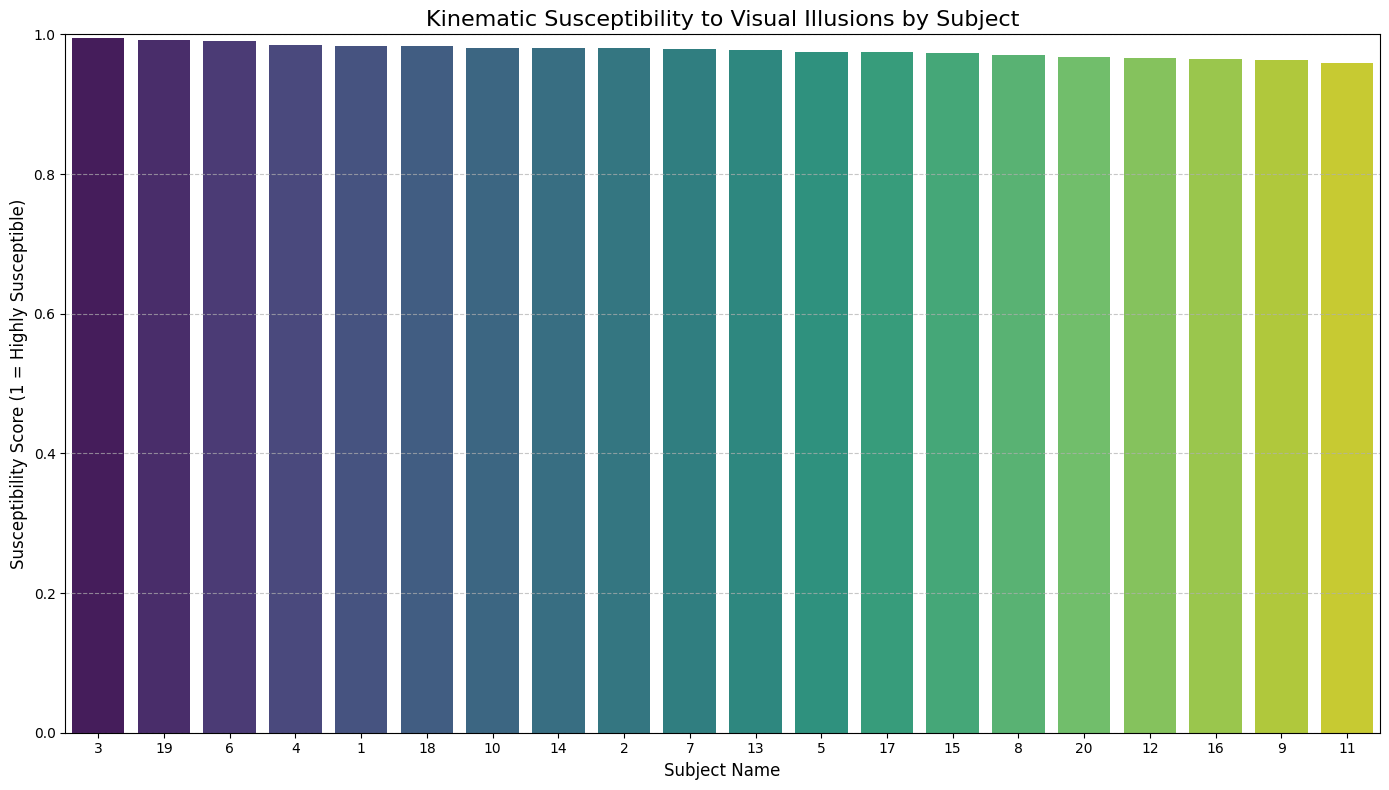

In [6]:
plt.figure(figsize=(14, 8))
sns.barplot(x='subjName', y='susceptibility_score', data=subject_scores,
            order=subject_scores['subjName'], palette='viridis')

plt.title('Kinematic Susceptibility to Visual Illusions by Subject', fontsize=16)
plt.xlabel('Subject Name', fontsize=12)
plt.ylabel('Susceptibility Score (1 = Highly Susceptible)', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("../../results/figures/illusion_susceptibility_by_subject.png")
plt.show()


C:\Users\bharg\AppData\Local\Temp\ipykernel_33964\2474396533.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


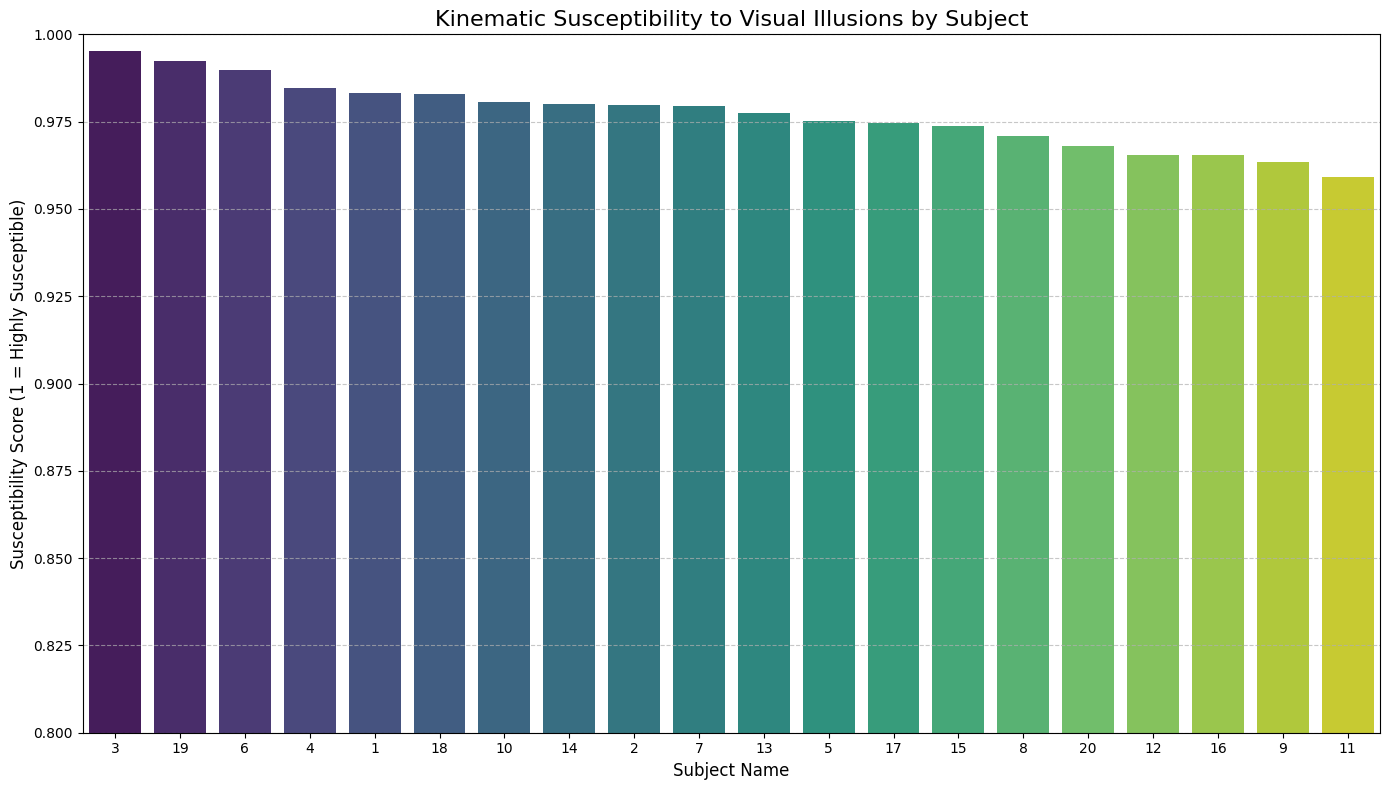

In [7]:
plt.figure(figsize=(14, 8))
sns.barplot(
    x='subjName',
    y='susceptibility_score',
    data=subject_scores,
    order=subject_scores['subjName'],
    palette='viridis'
)

plt.title('Kinematic Susceptibility to Visual Illusions by Subject', fontsize=16)
plt.xlabel('Subject Name', fontsize=12)
plt.ylabel('Susceptibility Score (1 = Highly Susceptible)', fontsize=12)

# Focus the y-axis starting at 0.8
plt.ylim(0.8, 1.0)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("../../results/figures/illusion_susceptibility_by_subject.png")
plt.show()


Subject 3 is the most susceptible, with a score near 1.0. This means their movements were the most distinct and easily classifiable. Subject 11 is the least susceptible, meaning their movements for the two illusion types were the most kinematically similar and ambiguous.


Least Susceptible Subjects: [16, 9, 11]
Most Susceptible Subjects: [3, 19, 6]


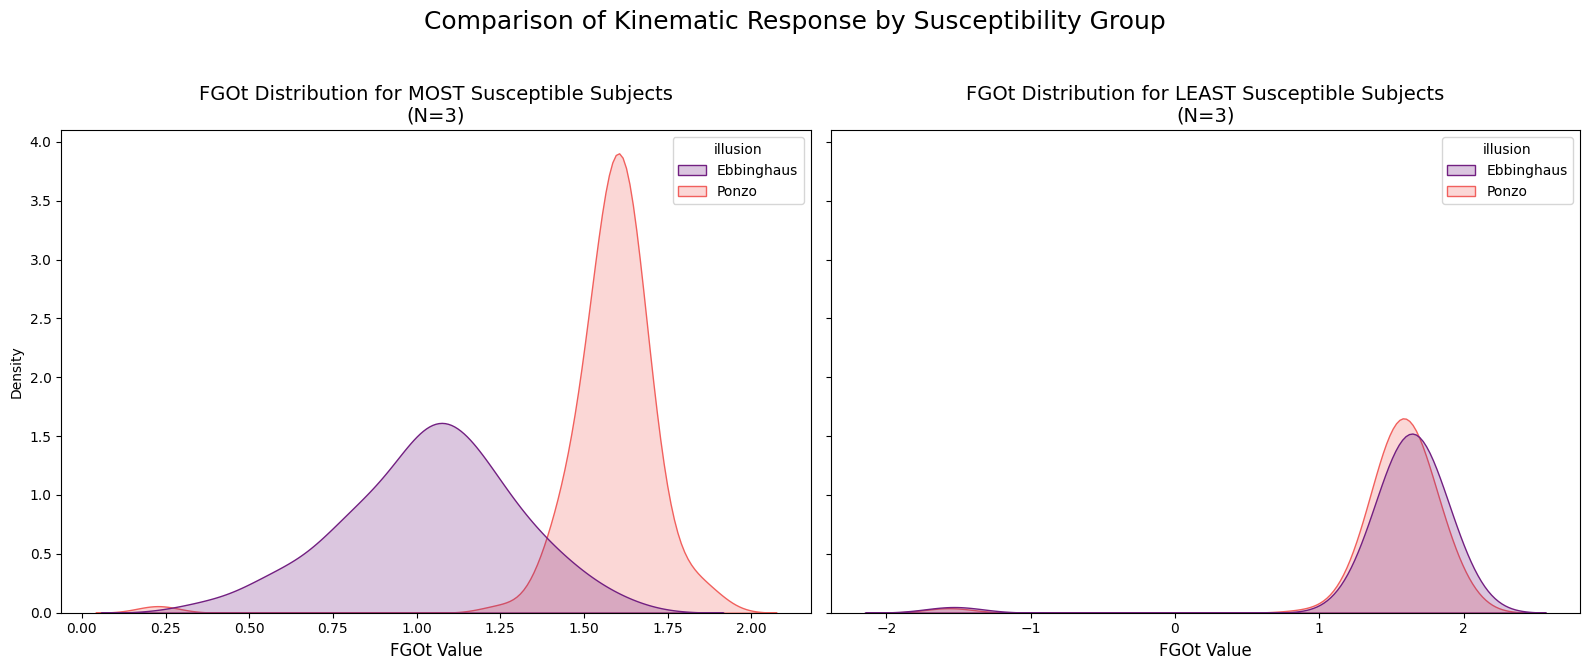

In [ ]:
# Kinematic Deep Dive

# Identify the most and least susceptible subjects
n_subjects_to_compare = 3
least_susceptible_subjects = subject_scores.tail(n_subjects_to_compare)['subjName'].tolist()
most_susceptible_subjects = subject_scores.head(n_subjects_to_compare)['subjName'].tolist()

print(f"\nLeast Susceptible Subjects: {least_susceptible_subjects}")
print(f"Most Susceptible Subjects: {most_susceptible_subjects}")

df_least = df_illusions[df_illusions['subjName'].isin(least_susceptible_subjects)]
df_most = df_illusions[df_illusions['subjName'].isin(most_susceptible_subjects)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Plot for MOST susceptible subjects
sns.kdeplot(data=df_most, x='FGOt', hue='illusion', fill=True, 
            common_norm=False, ax=axes[0], palette='magma')
axes[0].set_title(f'FGOt Distribution for MOST Susceptible Subjects\n(N={n_subjects_to_compare})', fontsize=14)
axes[0].set_xlabel('FGOt Value', fontsize=12)

# Plot for LEAST susceptible subjects
sns.kdeplot(data=df_least, x='FGOt', hue='illusion', fill=True, 
            common_norm=False, ax=axes[1], palette='magma')
axes[1].set_title(f'FGOt Distribution for LEAST Susceptible Subjects\n(N={n_subjects_to_compare})', fontsize=14)
axes[1].set_xlabel('FGOt Value', fontsize=12)

plt.suptitle('Comparison of Kinematic Response by Susceptibility Group', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("../../results/figures/illusion_kinematic_comparison_by_susceptibility.png")
plt.show()

The MOST Susceptible Subjects (Left Panel):

The distribution of the FGOt (Final Grip Orientation tangential) values for 'Ponzo' trials (red-orange) is highly separated from the distribution for 'Ebbinghaus' trials (purple). The 'Ponzo' movements consistently have much higher FGOt values.

The Insight: For these individuals, the visual illusion has a strong and reliable effect on their final hand posture. There is a clear, dramatic difference in how they shape their grip for each illusion. This clean separation in the key kinematic feature is precisely why the model could classify their movements so easily, resulting in their high susceptibility score.

The LEAST Susceptible Subjects (Right Panel):

The FGOt distributions for the two illusion types are heavily overlapped. While there might be a tiny shift, for the most part, a given FGOt value could plausibly belong to either a 'Ponzo' or an 'Ebbinghaus' trial.

The Insight: For these individuals, the illusion has a weak or inconsistent effect on their final grip orientation. Because their kinematic response is so similar across both conditions, the model is uncertain, leading to high ambiguity and a low susceptibility score.